# 04 — Modélisation Avancement (Modèle B)
## Jour 2, sous-étape 2d — Baseline tendance simple

Cible : `Avancement` (grain Département × Semaine, 20 semaines par département). Conformément au plan de mise en œuvre : *« modèle de tendance simple si le volume (20 points/série) ne justifie pas plus »* — pas de Gradient Boosting ici, le volume ne le justifie pas à ce stade.

La feuille `Toutes` (agrégat national) est exclue de cet exercice : c'est une moyenne dérivée des 4 départements, pas une série indépendante — l'inclure comme 5ᵉ "département" biaiserait toute évaluation globale.

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
import pickle

pd.set_option('display.max_columns', None)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

t_avnt = pd.read_csv('../data/processed/table_avancement_departement_semaine_anonymisee.csv', parse_dates=['Semaine'])
t_avnt = t_avnt[t_avnt['Departement'] != 'TOUTES'].sort_values(['Departement','Semaine']).reset_index(drop=True)
t_avnt['Semaine_Idx'] = t_avnt.groupby('Departement').cumcount() + 1
t_avnt.shape

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\_param_validation.py:14: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 2.5.0)
  from scipy.sparse import csr_matrix, issparse


(80, 11)

## 1. Découpage temporel — jamais de split aléatoire

Principe déjà établi dans ce projet (plan, section 5, piège n°1) : sur une série temporelle, le split entraînement/test doit toujours être chronologique. **16 premières semaines pour l'entraînement, 4 dernières pour le test** (horizons S+1 à S+4) — jamais un mélange aléatoire des semaines.

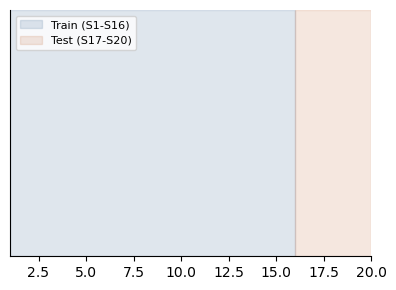

In [2]:
CUTOFF = 16  # semaines 1-16 = train, 17-20 = test (S+1 à S+4)

fig, ax = plt.subplots(figsize=(4,3))
ax.axvspan(1, CUTOFF, alpha=0.15, color='#2E5A8C', label='Train (S1-S16)')
ax.axvspan(CUTOFF, 20, alpha=0.15, color='#C0622D', label='Test (S17-S20)')
ax.set_xlim(1,20)
ax.set_yticks([])
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 2. Deux baselines à comparer

- **Persistance naïve** : la valeur observée à S16 reste constante pour toutes les semaines futures. C'est le baseline standard en série temporelle (équivalent du « prédire la moyenne » du guide, adapté au cas temporel).
- **Tendance linéaire simple** : régression `Avancement ~ Jours_Ecoules_Depuis_Debut_Chantier`, entraînée uniquement sur les 16 premières semaines, extrapolée sur les 4 suivantes. C'est le modèle demandé par le plan pour ce volume de données.

In [3]:
resultats = []
modeles = {}

for dep in t_avnt['Departement'].unique():
    sub = t_avnt[t_avnt['Departement']==dep].sort_values('Semaine_Idx')
    train = sub[sub['Semaine_Idx'] <= CUTOFF]
    test = sub[sub['Semaine_Idx'] > CUTOFF]

    lin = LinearRegression().fit(train[['Jours_Ecoules_Depuis_Debut_Chantier']], train['Avancement'])
    modeles[dep] = lin
    pred_tendance = lin.predict(test[['Jours_Ecoules_Depuis_Debut_Chantier']])

    derniere_valeur_train = train['Avancement'].iloc[-1]
    pred_naif = np.full(len(test), derniere_valeur_train)

    for i, (_, row) in enumerate(test.iterrows()):
        horizon = int(row['Semaine_Idx'] - CUTOFF)
        resultats.append({
            'Departement': dep, 'Horizon': f"S+{horizon}",
            'Reel': row['Avancement'], 'Pred_Tendance': pred_tendance[i], 'Pred_Naif': pred_naif[i],
        })

res = pd.DataFrame(resultats)
res['Erreur_Tendance'] = (res['Reel'] - res['Pred_Tendance']).abs()
res['Erreur_Naif'] = (res['Reel'] - res['Pred_Naif']).abs()
res

,Departement,Horizon,Reel,Pred_Tendance,Pred_Naif,Erreur_Tendance,Erreur_Naif
0,ALIBORI,S+1,48.09,47.801500,45.45,0.288500,2.64
1,ALIBORI,S+2,51.91,49.574103,45.45,2.335897,6.46
2,ALIBORI,S+3,54.00,51.346706,45.45,2.653294,8.55
3,ALIBORI,S+4,54.00,53.119309,45.45,0.880691,8.55
4,ATACORA,S+1,62.29,60.314000,59.43,1.976000,2.86
5,ATACORA,S+2,65.71,62.187118,59.43,3.522882,6.28
6,ATACORA,S+3,67.86,64.060235,59.43,3.799765,8.43
7,ATACORA,S+4,67.86,65.933353,59.43,1.926647,8.43
8,BORGOU,S+1,36.81,31.458000,35.19,5.352000,1.62
9,BORGOU,S+2,38.56,32.874603,35.19,5.685397,3.37


In [4]:
print("=== MAE par horizon (points de %) ===")
print(res.groupby('Horizon')[['Erreur_Tendance','Erreur_Naif']].mean().round(2))
print()
print("=== MAE global (S+1 à S+4 confondus) ===")
print(f"Tendance linéaire : {res['Erreur_Tendance'].mean():.2f} points de %")
print(f"Persistance naïve : {res['Erreur_Naif'].mean():.2f} points de %")

=== MAE par horizon (points de %) ===
         Erreur_Tendance  Erreur_Naif
Horizon                              
S+1                 3.19         2.23
S+2                 4.09         4.47
S+3                 5.60         7.34
S+4                 4.25         7.34

=== MAE global (S+1 à S+4 confondus) ===
Tendance linéaire : 4.28 points de %
Persistance naïve : 5.34 points de %


**Constat central :** le classement entre les deux baselines **dépend de l'horizon**, ce qui est une leçon en soi.

- À très court terme (**S+1**), la persistance naïve est légèrement meilleure (MAE 2,23 vs 3,19) : sur une semaine, l'avancement ne bouge pas assez pour qu'extrapoler une tendance apporte un avantage net.
- À mesure que l'horizon s'allonge, la tendance prend l'avantage : à **S+4**, elle réduit l'erreur de près de moitié (4,25 contre 7,34 pour le naïf) — logique, la persistance suppose qu'aucun progrès ne se produit, une hypothèse de moins en moins tenable au fil des semaines.

Ce résultat confirme, dans un cas concret, le principe du guide de référence (section 3.2) : comparer systématiquement à un modèle naïf, plutôt que de supposer qu'un modèle « plus élaboré » gagne automatiquement.

## 3. Visualisation département par département

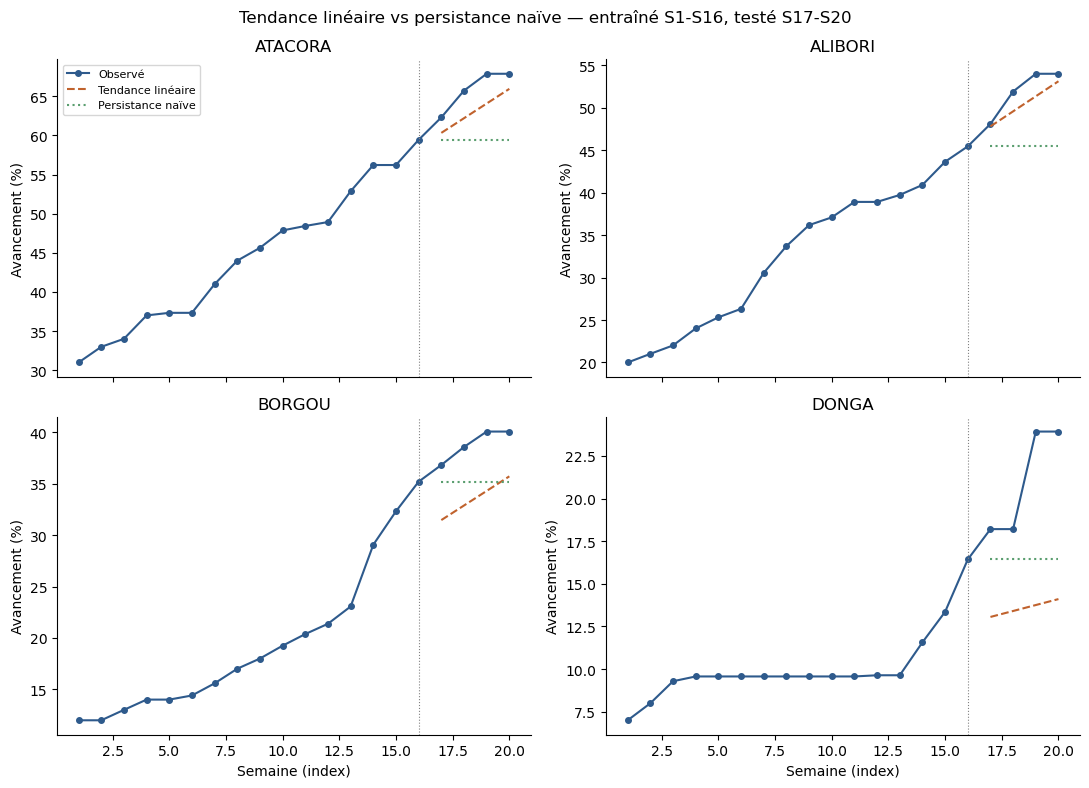

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11,8), sharex=True)
for ax, dep in zip(axes.flat, ['ATACORA','ALIBORI','BORGOU','DONGA']):
    sub = t_avnt[t_avnt['Departement']==dep].sort_values('Semaine_Idx')
    train = sub[sub['Semaine_Idx'] <= CUTOFF]
    test = sub[sub['Semaine_Idx'] > CUTOFF]

    pred_tendance = modeles[dep].predict(test[['Jours_Ecoules_Depuis_Debut_Chantier']])
    pred_naif = np.full(len(test), train['Avancement'].iloc[-1])

    ax.plot(sub['Semaine_Idx'], sub['Avancement'], 'o-', color='#2E5A8C', label='Observé', markersize=4)
    ax.plot(test['Semaine_Idx'], pred_tendance, '--', color='#C0622D', label='Tendance linéaire')
    ax.plot(test['Semaine_Idx'], pred_naif, ':', color='#5A9E6F', label='Persistance naïve')
    ax.axvline(CUTOFF, color='gray', linewidth=0.8, linestyle=':')
    ax.set_title(dep)
    ax.set_ylabel('Avancement (%)')

axes[0,0].legend(fontsize=8, loc='upper left')
axes[1,0].set_xlabel('Semaine (index)')
axes[1,1].set_xlabel('Semaine (index)')
plt.suptitle('Tendance linéaire vs persistance naïve — entraîné S1-S16, testé S17-S20')
plt.tight_layout()
plt.show()

**Constat — le cas Donga fait le lien avec l'EDA (2b) :** c'est le département où la tendance linéaire se trompe le plus (MAE jusqu'à 10,2 points en S+3). La raison est visible sur le graphique : le plateau de stagnation de 9 semaines détecté en 2b (semaines ~3 à 13) est *inclus dans la période d'entraînement* — il tire la pente ajustée vers le bas. Le modèle ne peut donc pas anticiper le rattrapage brutal observé en semaines 17-19. C'est une limite structurelle d'une tendance linéaire simple face à une dynamique par paliers (stagnation puis rattrapage), pas un problème d'implémentation — et un argument concret pour explorer, si le Jour 3 le justifie, un modèle capable de capter ce type de rupture (ex. variable de « nombre de semaines sans progression » en entrée d'un modèle plus riche).

## 4. Sauvegarde des modèles

Un modèle de tendance par département (4 objets `LinearRegression`), sauvegardés ensemble dans un seul fichier — plus simple qu'un `Pipeline` scikit-learn complet ici, car il n'y a qu'une seule variable d'entrée (le temps écoulé), sans prétraitement catégoriel à encapsuler.

In [6]:
import os
os.makedirs('../models', exist_ok=True)
with open('../models/model_B_avancement_tendance.pkl', 'wb') as f:
    pickle.dump(modeles, f)
print("Sauvegardé : models/model_B_avancement_tendance.pkl (1 modèle de tendance par département)")

Sauvegardé : models/model_B_avancement_tendance.pkl (1 modèle de tendance par département)


## 5. Bilan de la sous-étape 2d

| Point vérifié | Résultat |
|---|---|
| Découpage temporel | Chronologique (S1-S16 train / S17-S20 test), aucun split aléatoire |
| Baseline naïve (persistance) | Compétitive à S+1 (MAE 2,23), décroche à S+4 (MAE 7,34) |
| Tendance linéaire | Moins bonne à S+1 (MAE 3,19), nettement meilleure à S+4 (MAE 4,25) |
| Cas Donga | Confirme le plateau détecté en 2b — la tendance sous-estime le rattrapage |
| Modèles sauvegardés | `models/model_B_avancement_tendance.pkl` (4 modèles, 1 par département) |

**Prochaine étape (à valider) :** 2e — baseline régression logistique pour le Modèle C (risque de retard).